In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix # اضافه کردن confusion_matrix
import sklearn.preprocessing as preprocessing
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.inspection import permutation_importance

In [5]:
# مسیر کامل فایل CSV
file_path = r'D:\پروپوزال\My_Data_Output payanname.csv'

# خواندن فایل (با پشتیبانی از فارسی)
df = pd.read_csv(file_path, encoding='utf-8-sig')

# نمایش چند سطر اول برای اطمینان
print(df.head())

   CPAP-BIPAP  T-PIECE  با اکسیژن  خود بخودی  خودبخودی -بااکسیژن /I-PICE  \
0           0        0          1          0                           0   
1           0        0          0          0                           0   
2           0        0          0          1                           0   
3           0        0          0          1                           0   
4           0        0          1          0                           0   

   ونتیلاتور  سطح مرکز  سن بیمار  وضعیت ترخیص رمزگذاری شده  \
0          0         1        79                       1.0   
1          1         1        39                       0.0   
2          0         1        73                       1.0   
3          0         1        64                       0.0   
4          0         1        50                       0.0   

   بیماری زمینه ای رمزگذاری شده  ...  تشک مواج  سایر  عصا  عصا/واکر  واکر  \
0                             0  ...         0     1    0         0     0   
1               

In [6]:
df

,CPAP-BIPAP,T-PIECE,با اکسیژن,خود بخودی,خودبخودی -بااکسیژن /I-PICE,ونتیلاتور,سطح مرکز,سن بیمار,وضعیت ترخیص رمزگذاری شده,بیماری زمینه ای رمزگذاری شده,...,تشک مواج,سایر,عصا,عصا/واکر,واکر,ویلچر,اکسیژن ساز,ساکشن,کمک تنفسی نیاز ندارد,کپسول اکسیژن
0,0,0,1,0,0,0,1,79,1.0,0,...,0,1,0,0,0,0,0,0,1,0
1,0,0,0,0,0,1,1,39,0.0,1,...,1,0,0,1,0,0,1,0,0,1
2,0,0,0,1,0,0,1,73,1.0,0,...,0,1,0,0,0,0,0,0,1,0
3,0,0,0,1,0,0,1,64,0.0,0,...,0,1,0,0,0,0,0,1,0,0
4,0,0,1,0,0,0,1,50,0.0,1,...,1,0,0,0,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
926,0,0,0,0,0,1,1,35,1.0,1,...,1,0,0,1,0,0,1,1,0,1
927,0,0,0,0,1,0,1,68,1.0,1,...,1,0,0,0,0,0,1,0,0,1
928,0,0,0,0,0,1,1,64,1.0,0,...,1,0,0,1,0,0,1,1,0,1
929,0,0,0,0,0,1,1,64,1.0,0,...,0,1,0,0,0,0,0,0,1,0


In [7]:
print(df.columns)

Index(['CPAP-BIPAP', 'T-PIECE', 'با اکسیژن', 'خود بخودی',
       'خودبخودی -بااکسیژن /I-PICE', 'ونتیلاتور', 'سطح مرکز', 'سن بیمار',
       'وضعیت ترخیص رمزگذاری شده', 'بیماری زمینه ای رمزگذاری شده',
       'تمایل به استفاده از خدمات مراقبت در منزلرمز گذاری شده',
       'نیاز به ویزیت پزشک در منزل کد گذاری شده', 'تشخیص_تروما',
       'تشخیص_روانپزشکی', 'تشخیص_سایر', 'تشخیص_سرطان', 'تشخیص_سوختگی',
       'تشخیص_سیستم تنفسی', 'تشخیص_سیستم عصبی مرکزی', 'تشخیص_سیستم قلبی',
       'تشخیص_سیستم کلیوی', 'تشخیص_سیستم گوارشی و غدد', 'تشخیص_عفونی',
       'تشخیص_لیپوساکشن', 'تشخیص_مسمومیت', 'NRS_اکسیژن تراپی', 'NRS_تزریق',
       'NRS_تعویض کاتتر یا سوند مثانه', 'NRS_تنظیم دستگاه', 'NRS_حمام در منزل',
       'NRS_خارج کردن سوند ادراری', 'NRS_سایر', 'NRS_سرم تراپی در منزل',
       'NRS_لوله گذاری', 'NRS_مراقبت پرستاری', 'NRS_پانسمان زخم',
       'NRS_پایش و ارزیابی بیمار', 'NRS_کنترل علائم حیاتی مجدد', 'NRS_گاواژ',
       'بدون زخم', 'زخم بستر', 'زخم جراحی', 'زخم پای دیابتی',
       'Level_سطح 2 (

In [8]:
# مثال: اگر نام ستون 'سن ' بود
# تعداد کل موارد در ستون 'سن ' (شامل None)
total_count = df['NRS_گاواژ'].count()

# شمارش فراوانی هر مقدار منحصربه‌فرد
value_counts = df['NRS_گاواژ'].value_counts()
 # کد اصلی (بدون تورفتگی اضافی)
df.columns = df.columns.str.strip()

print(value_counts)


NRS_گاواژ
0    921
1     10
Name: count, dtype: int64


In [9]:
target_column = 'سطح مرکز'

In [10]:
X = df.drop(columns=[target_column])

In [11]:
Y = df[target_column]

In [12]:
from sklearn.linear_model import LogisticRegression 

In [13]:
clf_lr=LogisticRegression()
clf_lr.fit(X,Y)

C:\Users\darman-it\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=0)

In [16]:
print(X_train.shape,X_test.shape,Y_train.shape,Y_test.shape)

(744, 80) (187, 80) (744,) (187,)


In [17]:
print("\nتوزیع کلاس‌ها قبل  از SMOTE:")
print(pd.Series(Y_train).value_counts())


توزیع کلاس‌ها قبل  از SMOTE:
سطح مرکز
1    657
2     87
Name: count, dtype: int64


In [18]:
clf_LR=LogisticRegression()
clf_LR.fit(X_train,Y_train)

C:\Users\darman-it\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [19]:
Y_test_pred=clf_LR.predict(X_test)

In [20]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [21]:
confusion_matrix(Y_test,Y_test_pred)

print(confusion_matrix(Y_test,Y_test_pred))
print(classification_report(Y_test, Y_test_pred))

[[170   3]
 [  8   6]]
              precision    recall  f1-score   support

           1       0.96      0.98      0.97       173
           2       0.67      0.43      0.52        14

    accuracy                           0.94       187
   macro avg       0.81      0.71      0.75       187
weighted avg       0.93      0.94      0.94       187



In [22]:
accuracy_score(Y_test,Y_test_pred)

0.9411764705882353

In [23]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# مدل SVM با کرنل شعاعی و در نظر گرفتن توازن کلاس
svm_model = SVC(kernel='rbf', class_weight='balanced', C=1.0, gamma='auto', random_state=42)
svm_model.fit(X_train, Y_train)

y_pred = svm_model.predict(X_test)

print(confusion_matrix(Y_test, y_pred))
print(classification_report(Y_test, y_pred))

[[130  43]
 [  5   9]]
              precision    recall  f1-score   support

           1       0.96      0.75      0.84       173
           2       0.17      0.64      0.27        14

    accuracy                           0.74       187
   macro avg       0.57      0.70      0.56       187
weighted avg       0.90      0.74      0.80       187



In [24]:
accuracy_score(Y_test,y_pred)

0.7433155080213903

## k_value = 9
print(f"\n--- آموزش مدل K-Nearest Neighbors (KNN) با K={k_value} ---")

knn_model = KNeighborsClassifier(n_neighbors=k_value)

# آموزش مدل بر روی داده‌های آموزشی متوازن
knn_model.fit(X_train, Y_train)
print("آموزش KNN به پایان رسید.")

# پیش‌بینی روی مجموعه آزمون
Y_test_pred_knn = knn_model.predict(X_test)

# ارزیابی عملکرد
accuracy_knn = accuracy_score(Y_test, Y_test_pred_knn)

print("\n--- نتایج ارزیابی مدل KNN (K=2) ---")
print(f"دقت (Accuracy) مدل KNN: {accuracy_knn:.4f}")
print("\nگزارش طبقه‌بندی (Classification Report) برای KNN:")
print(classification_report(Y_test, Y_test_pred_knn, zero_division=0))

In [25]:
from sklearn.neighbors import KNeighborsClassifier
clf_knn_1=KNeighborsClassifier(n_neighbors=2)
clf_knn_1.fit(X_train,Y_train)

,n_neighbors,2
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [26]:
confusion_matrix(Y_test,clf_knn_1.predict(X_test))

array([[173,   0],
       [ 13,   1]])

In [27]:
X_test

,CPAP-BIPAP,T-PIECE,با اکسیژن,خود بخودی,خودبخودی -بااکسیژن /I-PICE,ونتیلاتور,سن بیمار,وضعیت ترخیص رمزگذاری شده,بیماری زمینه ای رمزگذاری شده,تمایل به استفاده از خدمات مراقبت در منزلرمز گذاری شده,...,تشک مواج,سایر,عصا,عصا/واکر,واکر,ویلچر,اکسیژن ساز,ساکشن,کمک تنفسی نیاز ندارد,کپسول اکسیژن
386,0,0,0,0,1,0,85,0.0,0,1,...,1,0,0,1,0,0,1,1,0,1
496,0,0,0,0,1,0,60,1.0,0,1,...,0,1,0,0,0,0,1,0,0,1
878,0,0,1,0,0,0,16,1.0,1,0,...,1,0,0,0,0,0,0,0,0,1
910,0,0,0,1,0,0,85,1.0,1,1,...,1,0,0,0,0,0,0,0,1,0
478,0,0,0,0,1,0,72,1.0,0,1,...,1,0,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279,0,0,0,1,0,0,79,1.0,0,1,...,0,1,0,0,0,0,0,0,1,0
2,0,0,0,1,0,0,73,1.0,0,1,...,0,1,0,0,0,0,0,0,1,0
415,0,0,0,1,0,0,83,0.0,0,0,...,0,1,0,0,0,0,0,0,1,0
808,0,0,0,0,1,0,67,0.0,0,1,...,0,1,0,0,0,0,0,0,1,0


In [28]:
accuracy_score(Y_test,clf_knn_1.predict(X_test))

print(confusion_matrix(Y_test, clf_knn_1.predict(X_test)))
print(classification_report(Y_test, clf_knn_1.predict(X_test)))

[[173   0]
 [ 13   1]]
              precision    recall  f1-score   support

           1       0.93      1.00      0.96       173
           2       1.00      0.07      0.13        14

    accuracy                           0.93       187
   macro avg       0.97      0.54      0.55       187
weighted avg       0.94      0.93      0.90       187



In [93]:
accuracy_score(Y_test,clf_knn_1.predict(X_test))

0.93048128342246

In [94]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [95]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05)
model.fit(X_train, y_train)
preds = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, preds))
print(confusion_matrix(y_test, preds))
print(classification_report(y_test, preds))

Accuracy: 0.8823529411764706
[[159   8]
 [ 14   6]]
              precision    recall  f1-score   support

           1       0.92      0.95      0.94       167
           2       0.43      0.30      0.35        20

    accuracy                           0.88       187
   macro avg       0.67      0.63      0.64       187
weighted avg       0.87      0.88      0.87       187



In [96]:
scaler=preprocessing.StandardScaler().fit(X_test)
X_test=scaler.transform(X_test)

In [97]:
from sklearn import preprocessing
scaler=preprocessing.StandardScaler().fit(X_train)
X_train=scaler.transform(X_train)

In [98]:
print(f"Number of samples in X_train_s: {X_train.shape[0]}")
print(f"Number of samples in Y_train: {Y_train.shape[0]}")

Number of samples in X_train_s: 744
Number of samples in Y_train: 744


In [99]:
print(f"تعداد نمونه‌های کل در X (قبل از تقسیم): {X.shape[0]}")
print(f"تعداد نمونه‌های کل در Y (قبل از تقسیم): {Y.shape[0]}")

# سپس کد تقسیم داده‌های خود را اجرا کنید:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=0)

# و بلافاصله پس از آن، تعداد نمونه‌های X_train و Y_train را چک کنید:
print(f"تعداد نمونه‌ها در X_train (پس از تقسیم): {X_train.shape[0]}")
print(f"تعداد نمونه‌ها در Y_train (پس از تقسیم): {Y_train.shape[0]}")

تعداد نمونه‌های کل در X (قبل از تقسیم): 931
تعداد نمونه‌های کل در Y (قبل از تقسیم): 931
تعداد نمونه‌ها در X_train (پس از تقسیم): 744
تعداد نمونه‌ها در Y_train (پس از تقسیم): 744


In [100]:
clf_knn_1=KNeighborsClassifier(n_neighbors=2)
clf_knn_1.fit(X_train,Y_train)
accuracy_score(Y_test,clf_knn_1.predict(X_test))
print(confusion_matrix(Y_test, clf_knn_1.predict(X_test)))
print(classification_report(Y_test, clf_knn_1.predict(X_test)))

[[173   0]
 [ 13   1]]
              precision    recall  f1-score   support

           1       0.93      1.00      0.96       173
           2       1.00      0.07      0.13        14

    accuracy                           0.93       187
   macro avg       0.97      0.54      0.55       187
weighted avg       0.94      0.93      0.90       187



In [101]:
accuracy_score(Y_test,clf_knn_1.predict(X_test))

0.93048128342246

In [102]:
from sklearn.model_selection import GridSearchCV

In [103]:
params = {
    'n_neighbors': np.arange(1, 100) # آرایه از 1 تا 100
}

In [104]:
grid_search_cv=GridSearchCV(KNeighborsClassifier(),params)

In [105]:
grid_search_cv.fit(X_train,Y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'n_neighbors': array([ 1, 2..., 97, 98, 99])}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,np.int64(10)


## grid_search_cv.best_params_

In [106]:
optimised_KNN=grid_search_cv.best_estimator_

In [107]:
Y_test_pred=optimised_KNN.predict(X_test)

In [108]:
confusion_matrix(Y_test,Y_test_pred)

array([[173,   0],
       [ 14,   0]])

In [109]:
accuracy_score(Y_test,Y_test_pred)


0.9251336898395722

In [117]:
from imblearn.over_sampling import SMOTE
X_SMOT, y_SMOT = SMOTE().fit_resample(X, Y)

In [116]:

print("\nتوزیع کلاس‌ها بعد از SMOTE:")
print(pd.Series(y_SMOT).value_counts())


توزیع کلاس‌ها بعد از SMOTE:
سطح مرکز
1    830
2    830
Name: count, dtype: int64


In [119]:
print(X_SMOT.shape,y_SMOT.shape,X_SMOT.shape,y_SMOT.shape)

(1660, 80) (1660,) (1660, 80) (1660,)


In [51]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(Y_test, Y_test_pred))
print(confusion_matrix(Y_test, Y_test_pred))

              precision    recall  f1-score   support

           1       0.93      1.00      0.96       173
           2       0.00      0.00      0.00        14

    accuracy                           0.93       187
   macro avg       0.46      0.50      0.48       187
weighted avg       0.86      0.93      0.89       187

[[173   0]
 [ 14   0]]


C:\Users\darman-it\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\darman-it\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\darman-it\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

In [52]:
print(X_train.shape,X_test.shape,Y_train.shape,Y_test.shape)

(744, 80) (187, 80) (744,) (187,)


In [53]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [54]:
X_train, X_test, y_train, y_test = train_test_split(X_SMOT, y_SMOT, test_size=0.2, random_state=42)

model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05)
model.fit(X_train, y_train)
preds = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, preds))

Accuracy: 0.9457831325301205


In [55]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, preds))
print(confusion_matrix(y_test, preds))

              precision    recall  f1-score   support

           1       0.94      0.96      0.95       177
           2       0.95      0.93      0.94       155

    accuracy                           0.95       332
   macro avg       0.95      0.94      0.95       332
weighted avg       0.95      0.95      0.95       332

[[170   7]
 [ 11 144]]


In [56]:
from sklearn.svm import SVC
model = SVC(kernel='rbf', class_weight='balanced', probability=True)
model.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


In [57]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# مدل SVM با کرنل شعاعی و در نظر گرفتن توازن کلاس
svm_model = SVC(kernel='rbf', class_weight='balanced', C=1.0, gamma='auto', random_state=42)
svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[165  12]
 [  9 146]]
              precision    recall  f1-score   support

           1       0.95      0.93      0.94       177
           2       0.92      0.94      0.93       155

    accuracy                           0.94       332
   macro avg       0.94      0.94      0.94       332
weighted avg       0.94      0.94      0.94       332



In [194]:
print(X_train.shape,X_test.shape,Y_train.shape,Y_test.shape)

(1328, 80) (332, 80) (744,) (187,)


In [195]:
from sklearn.neighbors import KNeighborsClassifier
clf_knn_1=KNeighborsClassifier(n_neighbors=2)
clf_knn_1.fit(X_train,y_train)

,n_neighbors,2
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [196]:
accuracy_score(y_test,clf_knn_1.predict(X_test))

print(confusion_matrix(y_test, clf_knn_1.predict(X_test)))
print(classification_report(y_test, clf_knn_1.predict(X_test)))

[[152  25]
 [  2 153]]
              precision    recall  f1-score   support

           1       0.99      0.86      0.92       177
           2       0.86      0.99      0.92       155

    accuracy                           0.92       332
   macro avg       0.92      0.92      0.92       332
weighted avg       0.93      0.92      0.92       332



In [197]:
from sklearn.linear_model import LogisticRegression 

In [198]:
clf_lr=LogisticRegression()
clf_lr.fit(X,Y)

C:\Users\darman-it\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [199]:
from sklearn.model_selection import train_test_split

In [200]:
print(X_train.shape,X_test.shape,Y_train.shape,Y_test.shape)

(1328, 80) (332, 80) (744,) (187,)


In [201]:
X_train, X_test, y_train, y_test = train_test_split(X_SMOT, y_SMOT, test_size=0.2, random_state=42)


In [202]:
clf_LR=LogisticRegression()
clf_LR.fit(X_train,y_train)

C:\Users\darman-it\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [203]:
Y_test_pred=clf_LR.predict(X_test)

In [204]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [205]:
confusion_matrix(y_test,Y_test_pred)

print(confusion_matrix(y_test,Y_test_pred))
print(classification_report(y_test, Y_test_pred))

[[171   6]
 [  9 146]]
              precision    recall  f1-score   support

           1       0.95      0.97      0.96       177
           2       0.96      0.94      0.95       155

    accuracy                           0.95       332
   macro avg       0.96      0.95      0.95       332
weighted avg       0.95      0.95      0.95       332



In [213]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt

In [214]:

log_reg_model = LogisticRegression(solver='liblinear', random_state=42)
log_reg_model.fit(X_train, y_train) # فرض بر این است که X_train و Y_train تعریف شده‌اند

print("مدل Logistic Regression آموزش داده شد.")

مدل Logistic Regression آموزش داده شد.


--- اهمیت ویژگی‌ها با استفاده از Permutation Importance (Logistic Regression) ---
معیار ارزیابی: accuracy

ویژگی: NRS_خارج کردن سوند ادراری | اهمیت: 7.83%
ویژگی: تمایل به استفاده از خدمات مراقبت در منزلرمز گذاری شده | اهمیت: 2.02%
ویژگی: Level_سطح 3(مراقبت متوسط) | اهمیت: 1.48%
ویژگی: ندارد                | اهمیت: 1.02%
ویژگی: بیماری زمینه ایnan   | اهمیت: 0.93%
ویژگی: خود بخودی            | اهمیت: 0.93%
ویژگی: Level_سطح1(قادر به مراقبت از خود) | اهمیت: 0.93%
ویژگی: خودبخودی -بااکسیژن /I-PICE | اهمیت: 0.66%
ویژگی: بدون زخم             | اهمیت: 0.51%
ویژگی: تشخیص_سوختگی         | اهمیت: 0.48%
ویژگی: تشک مواج             | اهمیت: 0.36%
ویژگی: Level_سطح 4(مراقبت گسترده) | اهمیت: 0.36%
ویژگی: بیماری زمینه ای رمزگذاری شده | اهمیت: 0.33%
ویژگی: NRS_پانسمان زخم      | اهمیت: 0.33%
ویژگی: NRS_لوله گذاری       | اهمیت: 0.33%
ویژگی: بدون وسیله کمک حرکتی.1 | اهمیت: 0.30%
ویژگی: تشخیص_مسمومیت        | اهمیت: 0.27%
ویژگی: Level_سطح 2 (مراقبت جزئی) | اهمیت: 0.27%
ویژگی: Level_سطح 5(مراقبت ویژه) | اه

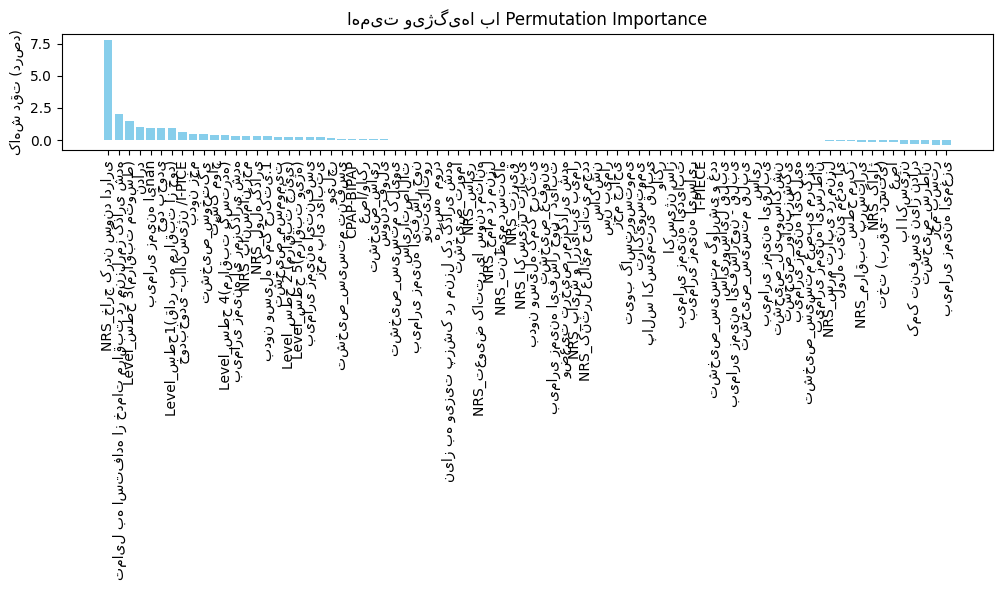

In [215]:
result = permutation_importance(
    log_reg_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='accuracy' # معیاری که برای ارزیابی کاهش دقت استفاده می‌شود (می‌تواند 'f1', 'recall' و ... باشد)
)

# --- نمایش نتایج ---

# مرتب‌سازی ویژگی‌ها بر اساس اهمیت (از بیشترین به کمترین)
sorted_idx = result.importances_mean.argsort()[::-1]

print("--- اهمیت ویژگی‌ها با استفاده از Permutation Importance (Logistic Regression) ---")
scoring_metric_used = 'accuracy' # یا 'recall' یا هر معیاری که خودتان انتخاب کردید
print(f"معیار ارزیابی: {scoring_metric_used}\n")

for i in sorted_idx:
    importance_percentage = result.importances_mean[i] * 100
    print(f"ویژگی: {feature_names[i]:<20} | اهمیت: {importance_percentage:.2f}%")

# --- نمایش گرافیکی اهمیت ویژگی‌ها (اختیاری) ---
plt.figure(figsize=(10, 6))
plt.bar(
    [feature_names[i] for i in sorted_idx],
    result.importances_mean[sorted_idx] * 100,
    color='skyblue'
)
plt.xticks(rotation=90)
plt.ylabel("کاهش دقت (درصد)")
plt.title("اهمیت ویژگی‌ها با Permutation Importance")
plt.tight_layout()
plt.show()

In [ ]:
print(len(X_SMOT), len(y_SMOT))  # این باید 1660 باشد
X_train, X_test, y_train, y_test = train_test_split(X_SMOT, y_SMOT, test_size=0.2, random_state=42)
print(X_train.shape, y_train.shape)  # تعداد نمونه‌ها باید برابر باشد
print(X_test.shape, y_test.shape)    # تعداد نمونه‌ها باید برابر باشد

In [ ]:
file_path = r'D:\پروپوزال\My_Data_Output payanname.csv'

target_column = 'سطح مرکز' # تارگت جدید شما

# --- 1. بارگذاری ایمن دیتافریم ---
print("--- مرحله 1: بارگذاری ایمن دیتافریم ---")
df = None  # اطمینان از مقداردهی اولیه متغیر df

try:
    # تلاش 1: encoding پیش‌فرض
    df = pd.read_csv(file_path)
    print(f"دیتافریم با موفقیت با encoding پیش‌فرض بارگذاری شد. ابعاد: {df.shape}")
except Exception as e1:
    print(f"خطا در بارگذاری با encoding پیش‌فرض ({e1}). تلاش با 'latin1'...")
    try:
        # تلاش 2: encoding latin1 (رایج برای فارسی)
        df = pd.read_csv(file_path, encoding='latin1')
        print(f"دیتافریم با موفقیت با encoding 'latin1' بارگذاری شد. ابعاد: {df.shape}")
    except Exception as e2:
        print(f"خطا در بارگذاری با 'latin1' نیز شکست خورد: {e2}")
        print("\n**اقدام لازم:** لطفاً مطمئن شوید که فایل 'My_Data_Output payanname.csv' دقیقاً در مسیر درستی قرار دارد و نام آن درست تایپ شده است. در غیر این صورت، ممکن است نیاز به یک encoding دیگر باشد.")
        # اگر df همچنان None باشد، اجرای مراحل بعدی متوقف خواهد شد.


# --- 2. ادامه پردازش (فقط اگر df تعریف شده باشد) ---
if df is not None and not df.empty:
    
    print("\n--- مرحله 2: جداسازی X و Y ---")
    cols_to_drop = [
       'بیماری زمینه ای رمزگذاری شده', 
        'بیماری زمینه ایnan',
       'وضعیت ترخیص رمزگذاری شده', 
        'تمایل به استفاده از خدمات مراقبت در منزلرمز گذاری شده',
        'نیاز به ویزیت پزشک در منزل کد گذاری شده'
    ] 

    # ایجاد X با حذف تارگت و ستون‌های نامرتبط
  #  X = df.drop(columns=[target_column] + [col for col in cols_to_drop if col in df.columns], errors='ignore')
  #  Y = df[target_column]

    # حذف سطرها با NaN در تارگت
    combined_df = pd.concat([X, Y], axis=1).dropna(subset=[target_column])
    X = combined_df.drop(columns=[target_column])
    Y = combined_df[target_column]
    
    # اطمینان از وجود تارگت
    if Y.empty or Y.nunique() < 2:
        print("\n**خطای داده‌ای:** متغیر تارگت ('سطح مرکز') یا خالی است یا تنها یک کلاس دارد. نمی‌توانیم SMOTE را اجرا کنیم.")
    else:
        # 3. بررسی توازن کلاس‌ها قبل از SMOTE
        print("\n--- مرحله 3: بررسی توازن قبل از SMOTE ---")
        print(f"توازن کلاس‌ها: {Counter(Y)}")

        # 4. پیاده‌سازی SMOTE
        print("\n--- مرحله 4: اجرای SMOTE ---")
        smote = SMOTE(random_state=42)
        X_res, Y_res = smote.fit_resample(X, Y)

        # 5. بررسی توازن کلاس‌ها بعد از SMOTE
        print(f"توازن کلاس‌ها بعد از SMOTE: {Counter(Y_res)}")

        # 6. تقسیم داده‌های متعادل شده به مجموعه آموزش و آزمون
        print("\n--- مرحله 5: تقسیم داده‌ها ---")
        X_train, X_test, Y_train, Y_test = train_test_split(X_res, Y_res, test_size=0.3, random_state=42, stratify=Y_res)

        print("\n*** آماده‌سازی داده‌ها با موفقیت انجام شد ***")
        print(f"اندازه مجموعه آموزش (X_train): {X_train.shape}")
        print(f"اندازه مجموعه آزمون (X_test): {X_test.shape}")
        
else:
    print("\n--- توقف پردازش ---")
    print("لطفاً مشکل بارگذاری فایل را برطرف کنید تا بتوانیم ادامه دهیم.")

In [ ]:
print(X_train.shape,X_test.shape,Y_train.shape,Y_test.shape)

In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from collections import Counter

# --- توجه: فرض می‌شود متغیرهای زیر از اجرای موفقیت‌آمیز کد قبلی شما باقی مانده‌اند: ---
# X_train, X_test, Y_train, Y_test

# --- مرحله 4: تعریف و آموزش مدل Logistic Regression ---
print("\n--- مرحله 4: آموزش و ارزیابی مدل Logistic Regression ---")

# تعریف مدل (با پارامترهای پیش‌فرض برای شروع)
# اگر کلاس‌های شما متعادل نیستند، تنظیم solver و max_iter ممکن است لازم باشد
# به دلیل استفاده از SMOTE، ممکن است Solver پیش‌فرض (lbfgs) مناسب باشد.
clf_LR = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)

print("شروع آموزش مدل با X_train...")
# آموزش مدل
clf_LR.fit(X_train, Y_train)
print("آموزش مدل با موفقیت به پایان رسید.")


# --- مرحله 5: پیش‌بینی و ارزیابی روی مجموعه آزمون ---
print("\n--- مرحله 5: پیش‌بینی و ارزیابی ---")

# پیش‌بینی روی مجموعه آزمون
Y_test_pred = clf_LR.predict(X_test)

# 1. محاسبه دقت (Accuracy)
accuracy = accuracy_score(Y_test, Y_test_pred)
print(f"دقت مدل (Accuracy) روی مجموعه آزمون: {accuracy:.4f}")

# 2. محاسبه ماتریس درهم‌ریختگی (Confusion Matrix)
conf_matrix = confusion_matrix(Y_test, Y_test_pred)
print("\nماتریس درهم‌ریختگی (Confusion Matrix):\n", conf_matrix)

# 3. گزارش کامل طبقه‌بندی (شامل Precision, Recall, F1-Score)
# توجه: اگر کلاس‌های شما '0' و '1' هستند، این گزارش آنها را نشان می‌دهد.
print("\nگزارش کامل طبقه‌بندی (Classification Report):\n")
print(classification_report(Y_test, Y_test_pred, zero_division=0))

# --- تحلیل نتایج ---
print("\n--- تحلیل اولیه ---")
if accuracy > 0.8:
    print("دقت مدل خوب به نظر می‌رسد. با توجه به استفاده از SMOTE، انتظار می‌رود عملکرد خوبی داشته باشد.")
elif accuracy < 0.55 and (Y_train.value_counts().iloc[0] / len(Y_train)) > 0.55:
    print("دقت مدل بسیار پایین است، شاید مدل نتوانسته است الگوهای پیچیده را یاد بگیرد یا نیاز به تنظیم پارامترها دارد.")
else:
    print("دقت مدل قابل قبول است، اما برای بهبود، باید Precision و Recall هر کلاس را بررسی کرد.")

In [ ]:
print(X_train.shape,X_test.shape,Y_train.shape,Y_test.shape)

In [ ]:

# --- آموزش مدل KNN با K=2 ---

k_value = 2
print(f"\n--- آموزش مدل K-Nearest Neighbors (KNN) با K={k_value} ---")

knn_model = KNeighborsClassifier(n_neighbors=k_value)

# آموزش مدل بر روی داده‌های آموزشی متوازن
knn_model.fit(X_train, Y_train)
print("آموزش KNN به پایان رسید.")

# پیش‌بینی روی مجموعه آزمون
Y_test_pred_knn = knn_model.predict(X_test)

# ارزیابی عملکرد
accuracy_knn = accuracy_score(Y_test, Y_test_pred_knn)

print("\n--- نتایج ارزیابی مدل KNN (K=2) ---")
print(f"دقت (Accuracy) مدل KNN: {accuracy_knn:.4f}")
print("\nگزارش طبقه‌بندی (Classification Report) برای KNN:")
print(classification_report(Y_test, Y_test_pred_knn, zero_division=0))

# --- مرحله بعدی: مقایسه با Logistic Regression ---
# مقایسه با نتایج قبلی LR: Accuracy=0.9217

# برای ارائه بهترین نتیجه، بهتر است Grid Search را برای KNN نیز انجام دهیم.
# آیا مایلید من به طور خودکار Grid Search را برای KNN (برای پیدا کردن بهترین K) اجرا کنم،
# یا ابتدا نتایج K=5 را بررسی کنیم؟

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
import numpy as np
import pandas as pd
# ... سایر ایمپورت‌های شما ...

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, recall_score, f1_score

# --- 1. بارگذاری داده‌ها و تعریف ویژگی‌ها/برچسب‌ها ---

file_path = r'D:\پروپوزال\My_Data_Output payanname.csv'

# خواندن فایل (با پشتیبانی از فارسی)
try:
    df = pd.read_csv(file_path, encoding='utf-8-sig')
except FileNotFoundError:
    print("خطا: فایل 'My_Data_Output payanname.csv' پیدا نشد. لطفاً از آپلود مجدد فایل اطمینان حاصل کنید.")
    exit()

# 81 ستون اول (0 تا 80) به عنوان ویژگی‌ها (X)
X = df.iloc[:, :81]
# ستون 8 به عنوان برچسب (Y)
Y_raw = df.iloc[:, 8]

# نگاشت برچسب‌ها: 1.0 (اقلیت) -> 1 و 0.0 (اکثریت) -> 2 (برای داشتن دو کلاس مجزا برای طبقه‌بندی)
Y = Y_raw.map({1.0: 1, 0.0: 2}).astype(int)

# --- 2. تقسیم داده‌ها ---
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

# --- 3. تعریف Pipeline و مدل پایه ---
# تعریف پارامترهای جستجو (بر اساس آنچه قبلاً مشخص شده بود)
pipeline_steps = [
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced'))
]

# پارامترهایی که قرار است جستجو شوند
param_grid = {
    'classifier__C': [0.1, 1.0, 10.0],
    'classifier__penalty': ['l1', 'l2']
}

# ساخت Pipeline
pipe = Pipeline(pipeline_steps)

# ساخت GridSearchCV
grid_search = GridSearchCV(
    pipe,
    param_grid,
    scoring={'recall_class_1': make_scorer(recall_score, pos_label=1),
             'f1_class_1': make_scorer(f1_score, pos_label=1)},
    refit='f1_class_1', # ملاک اصلی برای انتخاب بهترین مدل
    cv=5,
    verbose=1
)

# --- اجرای Grid Search (بخش اصلی آموزش) ---
print("\n--- شروع اجرای Grid Search (ممکن است چند دقیقه طول بکشد) ---")
grid_search.fit(X_train, Y_train)
print("--- پایان Grid Search ---")

# بهترین مدل پس از Grid Search
best_model = grid_search.best_estimator_

# --- 4. ارزیابی نهایی مدل انتخاب شده ---
Y_test_pred_final = best_model.predict(X_test)

print("\n" + "="*70)
print("--- نتایج نهایی ارزیابی بهترین مدل (Refitted on F1-Class-1) ---")
print(f"بهترین پارامترها: {grid_search.best_params_}")
print(f"بهترین امتیاز F1 (CV): {grid_search.best_score_:.4f}")
print(f"Accuracy نهایی روی مجموعه آزمون: {accuracy_score(Y_test, Y_test_pred_final):.4f}")

print("\nClassification Report نهایی روی مجموعه آزمون:")
# کلاس 1 (اقلیت) = Positive
target_names_persian = ['کلاس 1 (اقلیت)', 'کلاس 2 (اکثریت)']
print(classification_report(Y_test, Y_test_pred_final, target_names=target_names_persian, zero_division=0))
print("="*70)

# --- 5. محاسبه و نمایش Permutation Importance (بدون وابستگی به tabulate) ---
feature_names = X.columns.tolist()

print("\nشروع محاسبه Permutation Importance (با 10 تکرار بر روی داده آزمون)...")
r_import = permutation_importance(
    best_model, X_test, Y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# ایجاد DataFrame برای مرتب سازی نتایج
feature_importance_df = pd.DataFrame({
    'ویژگی (از ستون‌های CSV)': feature_names,
    'میانگین اهمیت (Mean Importance)': r_import.importances_mean,
    'انحراف معیار (Std)': r_import.importances_std
}).sort_values(by='میانگین اهمیت (Mean Importance)', ascending=False)

print("\n--- 15 ویژگی مهم برتر (Permutation Importance) ---")

# نمایش با استفاده از to_string() برای جلوگیری از خطای tabulate
print(feature_importance_df.head(15).to_string(index=False))

print("\n--- نتیجه‌گیری تحلیل ---")
print("با اجرای مجدد کد، اطمینان حاصل می‌کنیم که Grid Search به طور کامل اجرا شده است. لطفاً خروجی 'Classification Report نهایی' (به ویژه Recall برای کلاس اقلیت) و جدول '15 ویژگی مهم برتر' را بررسی کنید تا بفهمید کدام عوامل بیشترین تأثیر را بر پیش‌بینی داشته‌اند.")

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, make_scorer, recall_score, precision_score, f1_score # Import make_scorer here
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import numpy as np

# 1. بارگذاری داده
file_path = r'D:\پروپوزال\My_Data_Output payanname.csv'

# خواندن فایل (با پشتیبانی از فارسی)

df = pd.read_csv(file_path, encoding='utf-8-sig')

# 2. تعریف ویژگی‌ها (X) و برچسب (Y)
X = df.iloc[:, :81]
Y_raw = df.iloc[:, 8]

# نگاشت برچسب‌ها: 1.0 (اقلیت) -> 1 و 0.0 (اکثریت) -> 2
Y = Y_raw.map({1.0: 1, 0.0: 2}).astype(int)

# 3. تقسیم داده‌ها به مجموعه آموزش و آزمون
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

print(f"اندازه مجموعه آموزشی: {len(Y_train)}")
print(f"اندازه مجموعه آزمون: {len(Y_test)}")

# 4. تعریف Pipeline شامل SMOTE و Logistic Regression
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'recall_class_1': make_scorer(recall_score, average=None, labels=[1]), # Recall specifically for class 1
    'f1_class_1': make_scorer(f1_score, average=None, labels=[1]) # F1-score specifically for class 1
}

pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42))
])

# 5. تعریف فضای جستجو برای پارامترهای Logistic Regression
param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__class_weight': [None, 'balanced']
}

# 6. تنظیم GridSearchCV
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring=scoring,
    refit='accuracy',
    return_train_score=True,
    n_jobs=-1
)

# 7. اجرای Grid Search بر روی داده‌های آموزشی
print("\nشروع Grid Search...")
grid_search.fit(X_train, Y_train)
print("Grid Search به پایان رسید.")

# 8. نمایش بهترین پارامترها و امتیازات
print("\n--- بهترین پارامترهای یافت شده ---")
print(f"بهترین پارامترها: {grid_search.best_params_}")
print(f"بهترین امتیاز Accuracy: {grid_search.best_score_:.4f}")

results = pd.DataFrame(grid_search.cv_results_)
print("\n--- نتایج Grid Search (نمونه) ---")
print(results[['param_classifier__C', 'param_classifier__penalty', 'param_classifier__class_weight', 'mean_test_accuracy', 'mean_test_recall_class_1', 'mean_test_f1_class_1']].sort_values(by='mean_test_accuracy', ascending=False).head())


# 9. ارزیابی بهترین مدل بر روی مجموعه آزمون (X_test, Y_test)
best_model = grid_search.best_estimator_
Y_test_pred_gs = best_model.predict(X_test)

print("\n" + "="*50)
print("--- نتایج بهترین مدل Logistic Regression (پس از Grid Search) روی مجموعه آزمون ---")
print(f"Accuracy: {accuracy_score(Y_test, Y_test_pred_gs):.4f}")

print("\nClassification Report:")
print(classification_report(Y_test, Y_test_pred_gs, target_names=['Class 1 (Minority)', 'Class 2 (Majority)'], zero_division=0))
print("="*50)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.inspection import permutation_importance

# 1. بارگذاری داده‌ها
# فرض کنید داده‌ها در X و y قرار دارند
# X = pd.read_csv('data.csv') 
# y = X.pop('target')

# 2. تقسیم داده‌ها به مجموعه‌های آموزشی و تست
X_train, X_test, y_train, y_test = train_test_split(X_SMOT, y_SMOT, test_size=0.2, random_state=42)

# 3. آموزش مدل‌ها
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM': SVC(probability=True),
    'KNN': KNeighborsClassifier(),
    'Gradient Boosting': GradientBoostingClassifier()
}

# 4. ذخیره نتایج و اهمیت ویژگی‌ها
results = {}
importances = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    # محاسبه اهمیت ویژگی‌ها از Permutation Importance
    perm_importance = permutation_importance(model, X_test, y_test, n_repeats=30, random_state=42)
    importances[name] = perm_importance.importances_mean

# 5. نمایش نتایج
print("Accuracy Results:")
for name, acc in results.items():
    print(f"{name}: {acc:.4f}")

# 6. نمایش اهمیت ویژگی‌ها
importance_df = pd.DataFrame(importances, index=X.columns)
importance_df = importance_df.T
importance_df.plot(kind='bar', figsize=(10, 6))
plt.title("Feature Importances Using Permutation Importance")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.inspection import permutation_importance

# 2. تقسیم داده‌ها
X_train, X_test, y_train, y_test = train_test_split(
    X_SMOT, y_SMOT, test_size=0.2, random_state=42
)

# 3. آموزش مدل‌ها
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM': SVC(probability=False),  # سریع‌تر
    'KNN': KNeighborsClassifier(),
    'Gradient Boosting': GradientBoostingClassifier()
}

results = {}
importances = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc

    perm_importance = permutation_importance(
        model, X_test, y_test,
        n_repeats=10, random_state=42
    )
    importances[name] = perm_importance.importances_mean

print("Accuracy Results:")
for name, acc in results.items():
    print(f"{name}: {acc:.4f}")

# 6. نمایش اهمیت ویژگی‌ها
importance_df = pd.DataFrame(importances, index=X_SMOT.columns).T

importance_df.plot(kind='bar', figsize=(12, 6))
plt.title("Feature Importances Using Permutation Importance")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.inspection import permutation_importance

# 2. تقسیم داده‌ها
X_train, X_test, y_train, y_test = train_test_split(
    X_SMOT, y_SMOT, test_size=0.2, random_state=42
)

# 3. آموزش مدل‌ها
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM': SVC(probability=False),
    'KNN': KNeighborsClassifier(),
    'Gradient Boosting': GradientBoostingClassifier()
}

results = {}
importances = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc

    perm_importance = permutation_importance(
        model, X_test, y_test,
        n_repeats=10, random_state=42
    )
    importances[name] = perm_importance.importances_mean

# 5. چاپ دقت مدل‌ها
print("Accuracy Results:")
for name, acc in results.items():
    print(f"{name}: {acc:.4f}")

# 6. ساخت DataFrame اهمیت ویژگی‌ها (جدول کلی)
importance_df = pd.DataFrame(importances, index=X_SMOT.columns).T

print("\nTable of permutation importance (rows = models, columns = features):")
print(importance_df)

# 7. برای هر مدل، جدول مرتب‌شده ویژگی‌ها بر اساس اهمیت
for model_name in importance_df.index:
    print(f"\nFeature importance sorted for model: {model_name}")
    sorted_importance = importance_df.loc[model_name].sort_values(ascending=False)
    print(sorted_importance)

# 8. رسم نمودار (اگر دوست داری نمودار هم داشته باشی)
ax = importance_df.plot(kind='bar', figsize=(12, 6))
plt.title("Feature Importances Using Permutation Importance")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [35]:

import pandas as pd
import matplotlib.pyplot as plt
import arabic_reshaper
from bidi.algorithm import get_display


# Data for Class 1 before SMOTE
data_before = {
    "algoritm": ["Logistic Regression", "SVM (Linear Kernel)", "KNN (k=9)", "GradientBoostingClassifier"],
    "F1-Score": [0.97, 0.84, 0.97, 0.95]
}
df_before = pd.DataFrame(data_before)

# Data for Class 1 after SMOTE
data_after = {
    "algoritm": ["Logistic Regression", "SVM (Linear Kernel)", "KNN (k=9)", "GradientBoostingClassifier"],
    "F1-Score": [0.96, 0.94, 0.92, 0.95]
}
df_after = pd.DataFrame(data_after)

# Prepare labels for Persian rendering
models = ["Logistic Regression", "SVM (Linear Kernel)", "KNN (k=9)", "GradientBoostingClassifier"]
reshaped_labels = [get_display(arabic_reshaper.reshape(model)) for model in models]

plt.figure(figsize=(12, 7))

bar_width = 0.35
index = range(len(models))

# Before SMOTE bars
plt.bar(index, df_before["F1-Score"], bar_width, label=get_display(arabic_reshaper.reshape("قبل از SMOTE")), color='skyblue')

# After SMOTE bars
plt.bar([i + bar_width for i in index], df_after["F1-Score"], bar_width, label=get_display(arabic_reshaper.reshape("بعد از SMOTE")), color='lightcoral')

# Add labels, title, and legend
plt.xlabel(get_display(arabic_reshaper.reshape("الگوریتم")), fontsize=12)
plt.ylabel(get_display(arabic_reshaper.reshape("F1-Score")), fontsize=12)
plt.title(get_display(arabic_reshaper.reshape("مقایسه F1-Score کلاس 1 قبل و بعد از SMOTE")), fontsize=14)
plt.xticks([i + bar_width / 2 for i in index], reshaped_labels, rotation=45, ha="right")
plt.legend()
plt.tight_layout()

# Save the plot
plot_filename = "/mnt/data/class1_f1_score_comparison.png"
plt.savefig(plot_filename)

print(f"نمودار با موفقیت در {plot_filename} ذخیره شد.")
print("اطلاعات نمودار:")
print("قبل از SMOTE:")
print(df_before)
print("\nبعد از SMOTE:")
print(df_after)

ModuleNotFoundError: No module named 'arabic_reshaper'